<a href="https://colab.research.google.com/github/UnaSun2025/MSSP6070/blob/main/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
import numpy as np
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/MSSP607/data_academic_performance.csv')

In [32]:
df.columns

Index(['COD_S11', 'GENDER', 'EDU_FATHER', 'EDU_MOTHER', 'OCC_FATHER',
       'OCC_MOTHER', 'STRATUM', 'SISBEN', 'PEOPLE_HOUSE', 'Unnamed: 9',
       'INTERNET', 'TV', 'COMPUTER', 'WASHING_MCH', 'MIC_OVEN', 'CAR', 'DVD',
       'FRESH', 'PHONE', 'MOBILE', 'REVENUE', 'JOB', 'SCHOOL_NAME',
       'SCHOOL_NAT', 'SCHOOL_TYPE', 'MAT_S11', 'CR_S11', 'CC_S11', 'BIO_S11',
       'ENG_S11', 'Cod_SPro', 'UNIVERSITY', 'ACADEMIC_PROGRAM', 'QR_PRO',
       'CR_PRO', 'CC_PRO', 'ENG_PRO', 'WC_PRO', 'FEP_PRO', 'G_SC',
       'PERCENTILE', '2ND_DECILE', 'QUARTILE', 'SEL', 'SEL_IHE'],
      dtype='object')

In [33]:
hs = ['MAT_S11','CR_S11','CC_S11','BIO_S11','ENG_S11']
df['hs_mean'] = df[hs].mean(axis=1)
hs_mean = df['hs_mean']
hs_mean
hs_mean.describe()

,hs_mean
count,12411.000000
mean,62.311192
std,9.642924
min,35.800000
25%,55.200000
50%,61.800000
75%,69.000000
max,95.600000


In [34]:
s = pd.Series(hs_mean)
Q1 = s.quantile(0.25)
Q3 = s.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = s[(s < lower) | (s > upper)]
print("Outliers:", outliers)

Outliers: 1089     93.6
1799     95.6
2607     92.2
4373     91.0
4874     92.4
4900     91.4
5129     90.6
5199     92.0
5325     89.8
5576     90.0
5673     91.8
5872     94.6
6880     90.4
6991     90.2
7332     91.4
7340     90.6
7510     91.8
8877     91.6
8905     90.0
10096    91.2
10098    90.2
10550    91.4
10892    93.8
11642    91.0
11800    90.4
11864    90.4
11986    92.0
12003    92.2
12028    91.6
12063    90.0
12328    95.0
Name: hs_mean, dtype: float64


In [35]:
pro = ['QR_PRO','CR_PRO','CC_PRO','WC_PRO','ENG_PRO']
df['pro_mean'] = df[pro].mean(axis=1)
pro_mean = df['pro_mean']
pro_mean
pro_mean.describe()

,pro_mean
count,12411.000000
mean,64.001031
std,19.477674
min,3.000000
25%,50.000000
50%,66.000000
75%,79.600000
max,100.000000


In [36]:
s = pd.Series(pro_mean)
Q1 = s.quantile(0.25)
Q3 = s.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = s[(s < lower) | (s > upper)]
print("Outliers:", outliers)

Outliers: 813      4.6
1879     5.2
3061     4.2
3717     5.0
4258     5.6
7720     3.0
9242     5.2
12068    4.6
Name: pro_mean, dtype: float64


In [37]:
def classify_education(x):
    if pd.isna(x):
        return "UNKNOWN"

    s = str(x).strip().lower()

    s = s.replace("secundary", "secundary")

    if "postgrad" in s:
        return "POSTGRAD"
    elif "professional" in s:
        return "PROFESSIONAL"
    elif "tech" in s or "technical" in s or "technology" in s or "technique" in s or "tecnolog" in s:
        return "TECH/PROF"
    elif "secundary" in s:
        return "SECUNDARY"
    elif "primary" in s:
        return "PRIMARY"
    elif "not sure" in s or s in ["0", "unknown", "none","ninguno", ""]:
        return "UNKNOWN"
    else:
        return "UNKNOWN"

father_col = 'EDU_FATHER'
mother_col = 'EDU_MOTHER'

df["EDU_FATHER_BIN"] = df[father_col].apply(classify_education)
df["EDU_MOTHER_BIN"] = df[mother_col].apply(classify_education)

edu_order = {"UNKNOWN":0, "PRIMARY":1, "SECUNDARY":2, "TECH/PROF":3, "PROFESSIONAL":4, "POSTGRAD":5}

df["EDU_FATHER_SCORE"] = df["EDU_FATHER_BIN"].map(edu_order)
df["EDU_MOTHER_SCORE"] = df["EDU_MOTHER_BIN"].map(edu_order)

df["PARENT_EDU_SCORE"] = df[["EDU_FATHER_SCORE","EDU_MOTHER_SCORE"]].max(axis=1)
inv_map = {v:k for k,v in edu_order.items()}
df["PARENT_EDU_MAX"] = df["PARENT_EDU_SCORE"].map(inv_map)

print(df[["EDU_FATHER","EDU_MOTHER","PARENT_EDU_MAX"]].head(50))


                               EDU_FATHER  \
0       Incomplete Professional Education   
1                      Complete Secundary   
2                                Not sure   
3                                Not sure   
4         Complete professional education   
5         Complete professional education   
6         Complete professional education   
7                    Incomplete Secundary   
8                      Complete Secundary   
9   Incomplete technical or technological   
10                               Not sure   
11       Complete technique or technology   
12                               Not sure   
13        Complete professional education   
14                    Incomplete primary    
15       Complete technique or technology   
16        Complete professional education   
17        Complete professional education   
18       Complete technique or technology   
19        Complete professional education   
20        Complete professional education   
21        

In [38]:

print(df[['MAT_S11','CR_S11','CC_S11','BIO_S11','ENG_S11','hs_mean']].head())
print(df[['hs_mean']].head())
hs_by_parent = df.groupby("PARENT_EDU_MAX")["hs_mean"].mean()
print(df[['QR_PRO','CR_PRO','CC_PRO','WC_PRO','ENG_PRO','pro_mean']].head())
print(df[['pro_mean']].head())
pro_by_parent = df.groupby("PARENT_EDU_MAX")["pro_mean"].mean()

print(hs_by_parent)
print(pro_by_parent)

from scipy.stats import f_oneway
groups = [df[df["PARENT_EDU_MAX"]==cat]["pro_mean"].dropna()
          for cat in df["PARENT_EDU_MAX"].unique()]
f_stat, p_value = f_oneway(*groups)
print("ANOVA F-statistic:", f_stat)
print("p-value:", p_value)



   MAT_S11  CR_S11  CC_S11  BIO_S11  ENG_S11  hs_mean
0       71      81      61       86       82     76.2
1       83      75      66      100       88     82.4
2       52      49      38       46       42     45.4
3       56      55      51       64       73     59.8
4       80      65      76       85       92     79.6
   hs_mean
0     76.2
1     82.4
2     45.4
3     59.8
4     79.6
   QR_PRO  CR_PRO  CC_PRO  WC_PRO  ENG_PRO  pro_mean
0      71      93      71      79       93      81.4
1      97      38      86      78       98      79.4
2      17       1      18      22       43      20.2
3      65      35      76      48       80      60.8
4      94      94      98      71      100      91.4
   pro_mean
0      81.4
1      79.4
2      20.2
3      60.8
4      91.4
PARENT_EDU_MAX
POSTGRAD        68.488777
PRIMARY         58.285523
PROFESSIONAL    64.039169
SECUNDARY       59.353295
TECH/PROF       61.495735
UNKNOWN         58.255914
Name: hs_mean, dtype: float64
PARENT_EDU_MAX
POST

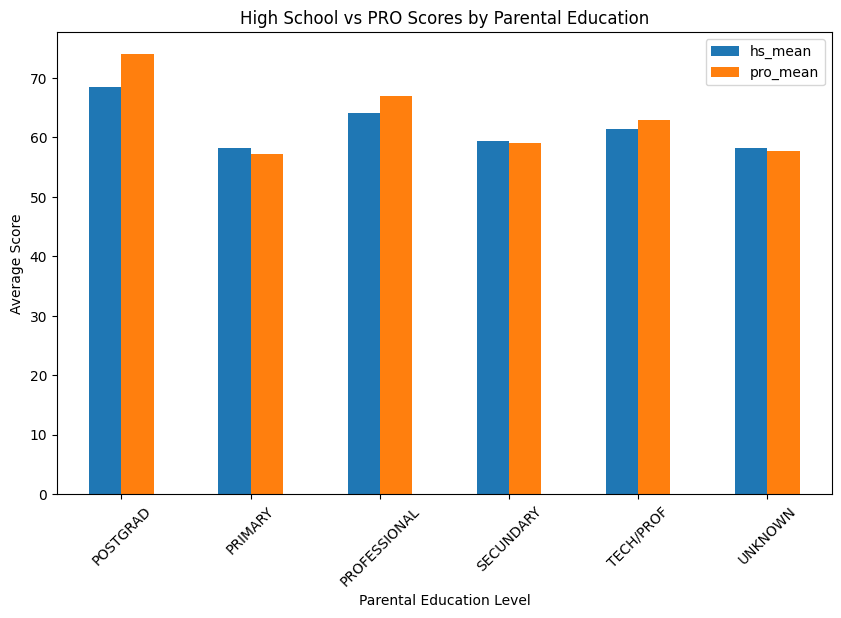

In [39]:
compare_df = pd.DataFrame({
    "hs_mean": hs_by_parent,
    "pro_mean": pro_by_parent})
import matplotlib.pyplot as plt
compare_df.plot(kind="bar", figsize=(10,6))
plt.title("High School vs PRO Scores by Parental Education")
plt.ylabel("Average Score")
plt.xlabel("Parental Education Level")
plt.xticks(rotation=45)
plt.show()

# **Q2 Which groups/stratums perform best? Are there differences btw groups/stratum?** #

In [40]:
df = pd.read_csv('/content/drive/MyDrive/MSSP607/data_academic_performance.csv')
df['hs_mean'] = df[['MAT_S11','CR_S11','CC_S11','BIO_S11','ENG_S11']].mean(axis=1)
df['pro_mean'] = df[['QR_PRO','CR_PRO','CC_PRO','WC_PRO','ENG_PRO']].mean(axis=1)
hs_by_stratum = df.groupby('STRATUM')['hs_mean'].mean()
pro_by_stratum = df.groupby('STRATUM')['pro_mean'].mean()
print(hs_by_stratum)
print(pro_by_stratum)

STRATUM
0            54.942857
Stratum 1    57.570158
Stratum 2    59.945098
Stratum 3    62.691125
Stratum 4    66.853485
Stratum 5    70.109637
Stratum 6    72.478908
Name: hs_mean, dtype: float64
STRATUM
0            55.742857
Stratum 1    55.044236
Stratum 2    60.298436
Stratum 3    65.202917
Stratum 4    71.828517
Stratum 5    75.668562
Stratum 6    78.248139
Name: pro_mean, dtype: float64


In [41]:
hs_by_stratum.describe()

,hs_mean
count,7.000000
mean,63.513038
std,6.547672
min,54.942857
25%,58.757628
50%,62.691125
75%,68.481561
max,72.478908


In [42]:
pro_by_stratum.describe()

,pro_mean
count,7.000000
mean,66.004809
std,9.450312
min,55.044236
25%,58.020647
50%,65.202917
75%,73.748540
max,78.248139


**high school group by 6 stratums**

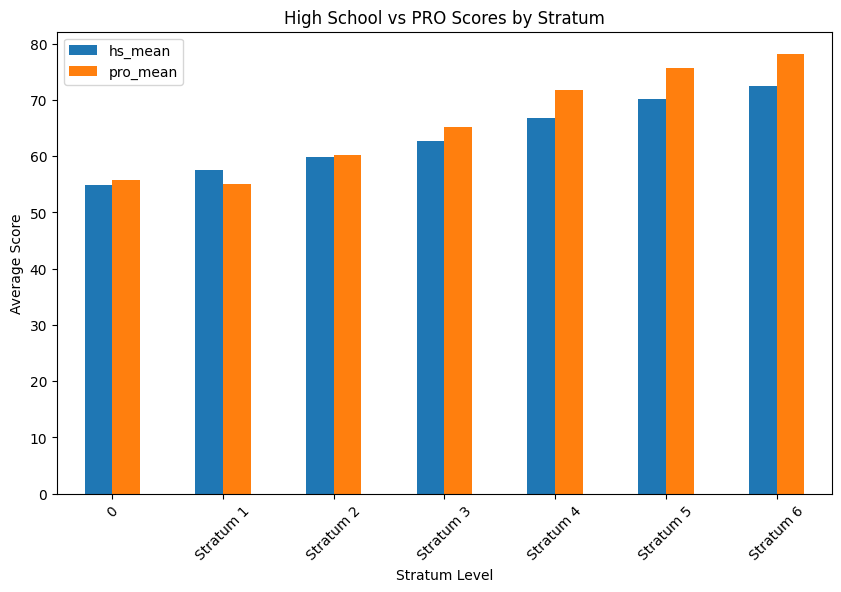

In [43]:
compare_df = pd.DataFrame({
    "hs_mean": hs_by_stratum,
    "pro_mean": pro_by_stratum})
import matplotlib.pyplot as plt
compare_df.plot(kind="bar", figsize=(10,6))
plt.title("High School vs PRO Scores by Stratum")
plt.ylabel("Average Score")
plt.xlabel("Stratum Level")
plt.xticks(rotation=45)
plt.show()

In [44]:
hs_summary = df.groupby('STRATUM')['hs_mean'].agg(
    count='count',
    mean='mean',
    std='std')
hs_summary


,count,mean,std
STRATUM,,,
0,14,54.942857,6.545194
Stratum 1,1709,57.570158,8.654374
Stratum 2,4029,59.945098,8.794136
Stratum 3,4045,62.691125,9.006968
Stratum 4,1578,66.853485,9.155412
Stratum 5,633,70.109637,8.963890
Stratum 6,403,72.478908,8.329199


In [45]:
hs_summary['ci95_low'] = hs_summary['mean'] - 1.96 * (hs_summary['std'] / hs_summary['count']**0.5)
hs_summary['ci95_high'] = hs_summary['mean'] + 1.96 * (hs_summary['std'] / hs_summary['count']**0.5)
print("=== High School (hs_mean) by STRATUM ===")
display(hs_summary)

=== High School (hs_mean) by STRATUM ===


,count,mean,std,ci95_low,ci95_high
STRATUM,,,,,
0,14,54.942857,6.545194,51.514275,58.371439
Stratum 1,1709,57.570158,8.654374,57.159840,57.980476
Stratum 2,4029,59.945098,8.794136,59.673548,60.216649
Stratum 3,4045,62.691125,9.006968,62.413553,62.968697
Stratum 4,1578,66.853485,9.155412,66.401754,67.305217
Stratum 5,633,70.109637,8.963890,69.411323,70.807951
Stratum 6,403,72.478908,8.329199,71.665691,73.292126


/tmp/ipython-input-574007250.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=df, x='STRATUM', y='hs_mean', estimator=np.mean, ci=95)


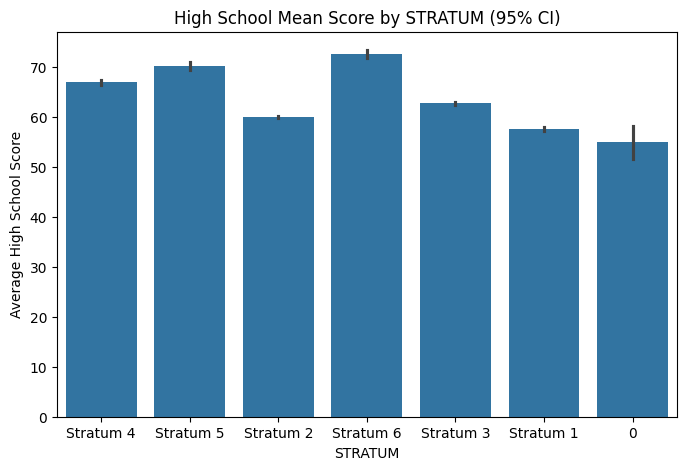

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))
sns.barplot(data=df, x='STRATUM', y='hs_mean', estimator=np.mean, ci=95)
plt.title('High School Mean Score by STRATUM (95% CI)')
plt.ylabel('Average High School Score')
plt.show()

**pro group by 6 stratums**

In [47]:
pro_summary = df.groupby('STRATUM')['pro_mean'].agg(
    count='count',
    mean='mean',
    std='std')
pro_summary


,count,mean,std
STRATUM,,,
0,14,55.742857,19.732898
Stratum 1,1709,55.044236,19.586772
Stratum 2,4029,60.298436,19.343875
Stratum 3,4045,65.202917,18.284819
Stratum 4,1578,71.828517,17.081819
Stratum 5,633,75.668562,15.979454
Stratum 6,403,78.248139,16.021955


In [48]:
pro_summary['ci95_low'] = pro_summary['mean'] - 1.96 * (pro_summary['std'] / pro_summary['count']**0.5)
pro_summary['ci95_high'] = pro_summary['mean'] + 1.96 * (pro_summary['std'] / pro_summary['count']**0.5)
print("=== Professional career exams (pro_mean) by STRATUM ===")
display(pro_summary)

=== Professional career exams (pro_mean) by STRATUM ===


,count,mean,std,ci95_low,ci95_high
STRATUM,,,,,
0,14,55.742857,19.732898,45.406133,66.079581
Stratum 1,1709,55.044236,19.586772,54.115595,55.972878
Stratum 2,4029,60.298436,19.343875,59.701125,60.895748
Stratum 3,4045,65.202917,18.284819,64.639426,65.766409
Stratum 4,1578,71.828517,17.081819,70.985694,72.671341
Stratum 5,633,75.668562,15.979454,74.423715,76.913410
Stratum 6,403,78.248139,16.021955,76.683842,79.812435


/tmp/ipython-input-219680613.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=df, x='STRATUM', y='pro_mean', estimator=np.mean, ci=95)


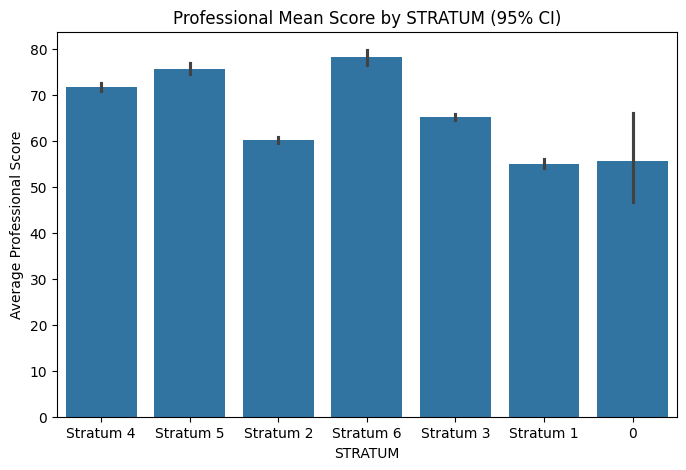

In [49]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='STRATUM', y='pro_mean', estimator=np.mean, ci=95)
plt.title('Professional Mean Score by STRATUM (95% CI)')
plt.ylabel('Average Professional Score')
plt.show()

**Q3 How does each gender perform in the global assessment?**

In [50]:
import numpy as np
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/MSSP607/data_academic_performance.csv')

data = df[["GENDER", "G_SC"]].dropna()

# Calculate descriptive statistics and assign to a variable
gender_stats = data.groupby("GENDER")["G_SC"].describe()

print("=== Global Assessment by Gender ===")
display(gender_stats)

# Calculate confidence intervals using the correct column names from gender_stats
gender_stats['ci95_low'] = gender_stats['mean'] - 1.96 * (gender_stats['std'] / gender_stats['count']**0.5)
gender_stats['ci95_high'] = gender_stats['mean'] + 1.96 * (gender_stats['std'] / gender_stats['count']**0.5)

print("\n=== Global Assessment by Gender with 95% CI ===")
display(gender_stats[['count', 'mean', 'std', 'ci95_low', 'ci95_high']])

=== Global Assessment by Gender ===


,count,mean,std,min,25%,50%,75%,max
GENDER,,,,,,,,
F,5043.0,161.278207,22.332939,76.0,146.0,162.0,177.0,242.0
M,7368.0,163.690825,23.582616,37.0,147.0,164.0,180.0,247.0



=== Global Assessment by Gender with 95% CI ===


,count,mean,std,ci95_low,ci95_high
GENDER,,,,,
F,5043.0,161.278207,22.332939,160.661815,161.89460
M,7368.0,163.690825,23.582616,163.152341,164.22931


In [51]:
bins = [0, 50, 100, 150, 200, 250]
labels = ['0-50','51-100','101-150','151-200','201-250']
df['G_SC_bin'] = pd.cut(df['G_SC'],bins = bins, labels = labels, include_lowest = True)

count_table = pd.crosstab(df['GENDER'],df['G_SC_bin'])
percent_table = pd.crosstab(df['GENDER'],df['G_SC_bin'],normalize = 'index')
count_table
percent_table

G_SC_bin,0-50,51-100,101-150,151-200,201-250
GENDER,,,,,
F,0.000000,0.002776,0.318263,0.648820,0.030141
M,0.000136,0.004479,0.289224,0.656759,0.049403


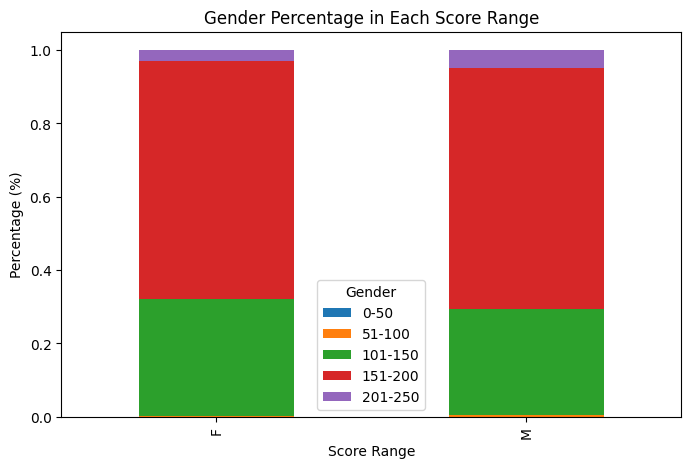

In [52]:
percent_table.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title('Gender Percentage in Each Score Range')
plt.ylabel('Percentage (%)')
plt.xlabel('Score Range')
plt.legend(title='Gender')
plt.show()

Mobile phone and computer

In [53]:

def device(row):
  if row['PHONE'] == 'Yes' and row['COMPUTER'] == 'Yes':
    return 'phone+pc'
  elif row['PHONE'] == 'Yes' and row['COMPUTER'] == 'No':
    return 'phone'
  elif row['PHONE'] == 'No' and row['COMPUTER'] == 'Yes':
    return 'pc'
  elif row['PHONE'] == 'No' and row['COMPUTER'] == 'No':
    return 'none'
  else:
    return 'unknown'

df['device'] = df.apply(device,axis=1)
df['device'].value_counts()

,count
device,
phone+pc,9841
phone,2049
pc,333
none,188


In [54]:
hs = ['MAT_S11','CR_S11','CC_S11','BIO_S11','ENG_S11']
if 'hs_mean' not in df.columns:
  df['hs_mean'] = df[hs].mean(axis=1)

hs_summary = df.groupby('device')['hs_mean'].agg(['count','mean','std'])
hs_summary['ci95_low'] = hs_summary['mean'] - 1.96 * (hs_summary['std'] / hs_summary['count']**0.5)
hs_summary['ci95_high'] = hs_summary['mean'] + 1.96 * (hs_summary['std'] / hs_summary['count']**0.5)
print("=== High School (hs_mean) by Device Group ===")
display(hs_summary)

=== High School (hs_mean) by Device Group ===


,count,mean,std,ci95_low,ci95_high
device,,,,,
none,188,60.203191,8.338776,59.011183,61.395200
pc,333,60.956757,8.446304,60.049562,61.863952
phone,2049,59.071742,8.831033,58.689361,59.454124
phone+pc,9841,63.071781,9.716034,62.879815,63.263748


In [55]:
# Ensure pro_mean is calculated
pro = ['QR_PRO','CR_PRO','CC_PRO','WC_PRO','ENG_PRO']
if 'pro_mean' not in df.columns:
  df['pro_mean'] = df[pro].mean(axis=1)

pro_summary = df.groupby('device')['pro_mean'].agg(['count','mean','std'])
pro_summary['ci95_low'] = pro_summary['mean'] - 1.96 * (pro_summary['std'] / pro_summary['count']**0.5)
pro_summary['ci95_high'] = pro_summary['mean'] + 1.96 * (pro_summary['std'] / pro_summary['count']**0.5)

print("=== Professional (pro_mean) by Device Group ===")
display(pro_summary)

=== Professional (pro_mean) by Device Group ===


,count,mean,std,ci95_low,ci95_high
device,,,,,
none,188,59.363830,20.015619,56.502643,62.225016
pc,333,62.042643,18.256961,60.081711,64.003574
phone,2049,58.276916,19.102159,57.449797,59.104034
phone+pc,9841,65.347709,19.351587,64.965366,65.730051


In [56]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model_hs = smf.ols('hs_mean ~ C(device)', data=df).fit()
anova_hs = sm.stats.anova_lm(model_hs, typ=2)
print(anova_hs)


                 sum_sq       df           F        PR(>F)
C(device)  2.864155e+04      3.0  105.261162  2.717514e-67
Residual   1.125315e+06  12407.0         NaN           NaN


In [57]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model_pro = smf.ols('pro_mean ~ C(device)', data=df).fit()
anova_pro = sm.stats.anova_lm(model_hs, typ=2)
print(anova_pro)


                 sum_sq       df           F        PR(>F)
C(device)  2.864155e+04      3.0  105.261162  2.717514e-67
Residual   1.125315e+06  12407.0         NaN           NaN
